# What Makes a Movie Profitable?

This project analyses movie data from TMDB to investigate the factors that influence movie profitability. The analysis focuses on budget, revenue, return on investment (ROI), genres, and release trends.



## Business Problem

Movie studios invest millions of dollars into film production. Understanding the factors that contribute to profitability can help studios make better investment decisions.

This project aims to answer the following questions:

1. Which genres are the most profitable?
2. Do larger budgets generate larger revenues?
3. Which films achieved the highest profits?
4. Which films achieved the highest ROI?
5. How has movie profitability changed over time?

## Data Loading

The dataset contains information on over 4,800 movies including budget, revenue, genres, popularity, release date, cast, crew and ratings.

The dataset is loaded into pandas for analysis.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb

In [17]:
df = pd.read_csv("/content/movie_dataset.csv")

## Initial Data Exploration

Before cleaning the data, an initial inspection was performed to understand the structure of the dataset, identify missing values and review available variables.

In [18]:
df.head()


,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [19]:
list(df.columns)

['index',
 'budget',
 'genres',
 'homepage',
 'id',
 'keywords',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'production_companies',
 'production_countries',
 'release_date',
 'revenue',
 'runtime',
 'spoken_languages',
 'status',
 'tagline',
 'title',
 'vote_average',
 'vote_count',
 'cast',
 'crew',
 'director']

In [20]:
# Checking how many missing values each column has

df.isnull().sum()

,0
index,0
budget,0
genres,28
homepage,3091
id,0
keywords,412
original_language,0
original_title,0
overview,3
popularity,0


In [21]:
# Checking for duplicate rows

df.duplicated().sum()

np.int64(0)

In [22]:
# Checking movies with zero budget or revenue

print("Movies with budget = 0:", (df['budget'] == 0).sum())
print("Movies with revenue = 0:", (df['revenue'] == 0).sum())

Movies with budget = 0: 1037
Movies with revenue = 0: 1427


## Data Cleaning

Several cleaning steps were performed to improve data quality.

Movies with missing budget or revenue values were removed. Movies with a budget or revenue of zero were also removed because profitability cannot be meaningfully calculated for these records.

In [23]:
# Create a copy so we don't modify original data

clean_df = df.copy()

In [24]:
# Remove movies with missing budget or revenue

clean_df = clean_df.dropna(subset=['budget', 'revenue'])

In [25]:
# Remove movies with budget or revenue equal to 0

clean_df = clean_df[
    (clean_df['budget'] > 0) &
    (clean_df['revenue'] > 0) ]

## Feature Engineering

New variables were created to support profitability analysis.

Profit = Revenue − Budget

ROI (Return on Investment) = Profit / Budget

Release Year was extracted from the release date to analyse trends over time.

In [26]:
# Create Profit column

clean_df['profit'] = clean_df['revenue'] - clean_df['budget']

In [27]:
# Create ROI column

clean_df['roi'] = clean_df['profit'] / clean_df['budget']

In [28]:
# Convert release date into datetime format

clean_df['release_date'] = pd.to_datetime(clean_df['release_date'])

In [29]:
# Create release year column

clean_df['release_year'] = clean_df['release_date'].dt.year

In [30]:
clean_df[['title','budget','revenue','profit','roi']].head()

,title,budget,revenue,profit,roi
0,Avatar,237000000,2787965087,2550965087,10.763566
1,Pirates of the Caribbean: At World's End,300000000,961000000,661000000,2.203333
2,Spectre,245000000,880674609,635674609,2.594590
3,The Dark Knight Rises,250000000,1084939099,834939099,3.339756
4,John Carter,260000000,284139100,24139100,0.092843


In [31]:
clean_df.to_csv("cleaned_movies.csv", index=False)
!ls

cleaned_movies.csv  drive  movie_dataset.csv  sample_data


## Genre Profitability Analysis

The first business question investigates whether certain genres are more profitable than others.

Initial results revealed that the dataset stores combinations of genres rather than individual genres, producing highly specific categories that require additional preprocessing for deeper genre analysis.

In [32]:
genre_profit = clean_df.groupby('genres')['profit'].mean()
genre_profit.sort_values(ascending=False).head(10)

,profit
genres,
Family Fantasy Adventure,8.254911e+08
Drama Action Crime Thriller,8.195584e+08
Family Adventure Drama Fantasy,7.915506e+08
Adventure Fantasy Family Mystery,7.882127e+08
Science Fiction Adventure Family Fantasy,7.824106e+08
Animation Comedy Adventure Family,7.822448e+08
Family Animation Drama,7.432418e+08
Drama Comedy Animation Family,6.826112e+08
Action Thriller Science Fiction Mystery Adventure,6.655328e+08


This genre profitability analysis reminded me that movies often contain multiple genres and here they are stored in a single field.

After some research if found that grouping by the full genre string produced combinations such as "Family Fantasy Adventure" and "Adventure Fantasy Family" as separate categories.

For me to obtain more meaningful insights, genres were split and analysed individually.

In [33]:
# Create a copy for genre analysis
genre_df = clean_df.copy()

# Split genres into lists
genre_df['genres'] = genre_df['genres'].str.split()

# Explode genres so each genre gets its own row
genre_df = genre_df.explode('genres')

genre_df.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,tagline,title,vote_average,vote_count,cast,crew,director,profit,roi,release_year
0,0,237000000,Action,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron,2550965087,10.763566,2009
0,0,237000000,Adventure,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron,2550965087,10.763566,2009
0,0,237000000,Fantasy,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron,2550965087,10.763566,2009
0,0,237000000,Science,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron,2550965087,10.763566,2009
0,0,237000000,Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron,2550965087,10.763566,2009


In [34]:
clean_df['genres'].head(20)

,genres
0,Action Adventure Fantasy Science Fiction
1,Adventure Fantasy Action
2,Action Adventure Crime
3,Action Crime Drama Thriller
4,Action Adventure Science Fiction
5,Fantasy Action Adventure
6,Animation Family
7,Action Adventure Science Fiction
8,Adventure Fantasy Family
9,Action Adventure Fantasy


Because the genre column stores multiple genres in one text field, simple splitting caused issues with genres such as "Science Fiction". To avoid incorrect splitting, I created a main_genre column using the first listed genre for each movie.

In [35]:
clean_df['main_genre'] = clean_df['genres'].str.split().str[0]

clean_df[['title', 'genres', 'main_genre']].head(10)

,title,genres,main_genre
0,Avatar,Action Adventure Fantasy Science Fiction,Action
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action,Adventure
2,Spectre,Action Adventure Crime,Action
3,The Dark Knight Rises,Action Crime Drama Thriller,Action
4,John Carter,Action Adventure Science Fiction,Action
5,Spider-Man 3,Fantasy Action Adventure,Fantasy
6,Tangled,Animation Family,Animation
7,Avengers: Age of Ultron,Action Adventure Science Fiction,Action
8,Harry Potter and the Half-Blood Prince,Adventure Fantasy Family,Adventure
9,Batman v Superman: Dawn of Justice,Action Adventure Fantasy,Action


In [36]:
genre_profit = clean_df.groupby('main_genre')['profit'].mean().sort_values(ascending=False)

genre_profit.head(10)

,profit
main_genre,
Animation,2.162605e+08
Family,1.722063e+08
Adventure,1.707187e+08
Science,1.461393e+08
Fantasy,1.196426e+08
Action,9.732282e+07
Romance,6.988704e+07
History,6.921722e+07
Mystery,6.598520e+07


## Genre Profitability Findings

Animation films generated the highest average profit, followed by Family and Adventure films.

These genres are commonly associated with large studio productions and globally successful franchises.

A limitation of this analysis is that only the first listed genre was used for each film. This was necessary because genres were stored as combined text strings and simple splitting incorrectly separated genres such as "Science Fiction".

## Does Budget Affect Profit?

One common assumption in the film industry is that bigger budgets lead to higher profits.

To investigate this, I analysed the relationship between movie budgets and profits.

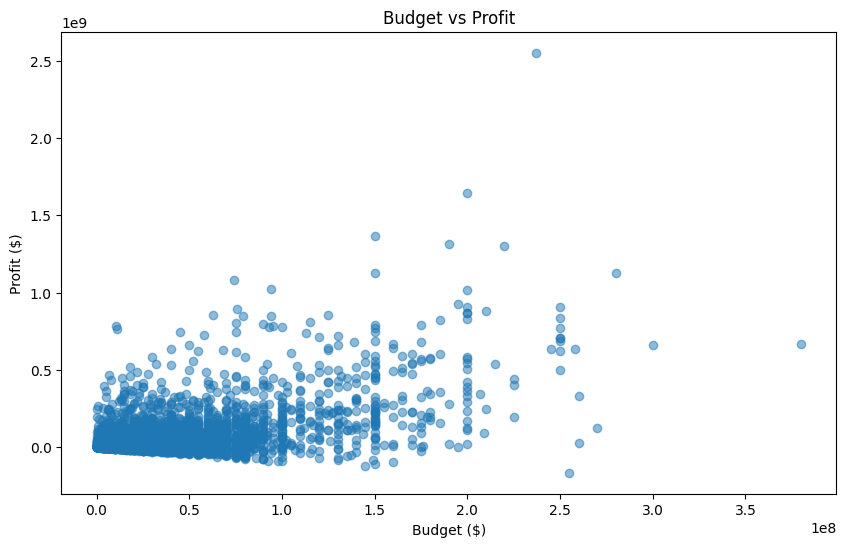

In [37]:
plt.figure(figsize=(10,6))

plt.scatter(
    clean_df['budget'],
    clean_df['profit'],
    alpha=0.5
)

plt.title('Budget vs Profit')
plt.xlabel('Budget ($)')
plt.ylabel('Profit ($)')

plt.show()

## Budget vs Profit Findings

The scatter plot shows a positive relationship between budget and profit.

Movies with larger budgets generally tend to generate higher profits. However, the relationship is not perfect, as some high-budget films generated relatively low profits while some lower-budget films performed exceptionally well.

This suggests that while budget is an important factor, other variables such as genre, marketing, release timing and audience reception also influence financial success.

In [38]:
clean_df[['budget', 'profit']].corr()

,budget,profit
budget,1.000000,0.550252
profit,0.550252,1.000000


## Correlation Analysis

The correlation between budget and profit was 0.55, indicating a moderate positive relationship.

This suggests that higher-budget films generally generate higher profits. However, the relationship is far from perfect, meaning that spending more money does not guarantee commercial success.

Other factors such as genre, marketing, franchise popularity and audience reception likely play important roles in determining profitability.

## Director Profitability Analysis

Directors can have a significant impact on a film's commercial performance.

This analysis investigates which directors generated the highest average profits across their movies.

In [39]:
director_profit = (
    clean_df.groupby('director')['profit']
    .mean()
    .sort_values(ascending=False)
)

director_profit.head(10)

,profit
director,
Chris Buck,1.124219e+09
Kyle Balda,1.082731e+09
Lee Unkrich,8.669697e+08
Joss Whedon,8.082770e+08
Chris Renaud,8.009583e+08
Roger Allers,7.432418e+08
James Cameron,7.338099e+08
Tim Miller,7.251130e+08
Pierre Coffin,6.846379e+08


## Director Profitability Findings

Several directors were associated with exceptionally profitable films.

Chris Buck, Kyle Balda and Lee Unkrich generated the highest average profits within the dataset.

However, these results should be interpreted cautiously because some directors may only have a small number of films represented. A single blockbuster movie can significantly influence the average profit calculation.

In [40]:
clean_df['director'].value_counts().head(20)

,count
director,
Steven Spielberg,27
Clint Eastwood,19
Martin Scorsese,16
Ridley Scott,16
Robert Rodriguez,16
Renny Harlin,15
Steven Soderbergh,14
Tim Burton,14
Robert Zemeckis,13


In [41]:
director_stats = clean_df.groupby('director').agg(
    movie_count=('title', 'count'),
    avg_profit=('profit', 'mean')
)

director_stats = director_stats[director_stats['movie_count'] >= 5]

director_stats.sort_values(
    by='avg_profit',
    ascending=False
).head(10)

,movie_count,avg_profit
director,,
James Cameron,7,7.338099e+08
George Lucas,5,5.958674e+08
Peter Jackson,9,5.784048e+08
Francis Lawrence,5,4.698914e+08
Christopher Nolan,8,4.028104e+08
Michael Bay,12,3.685437e+08
James Wan,6,3.494358e+08
Chris Columbus,9,3.462924e+08
Jon Favreau,6,3.003090e+08


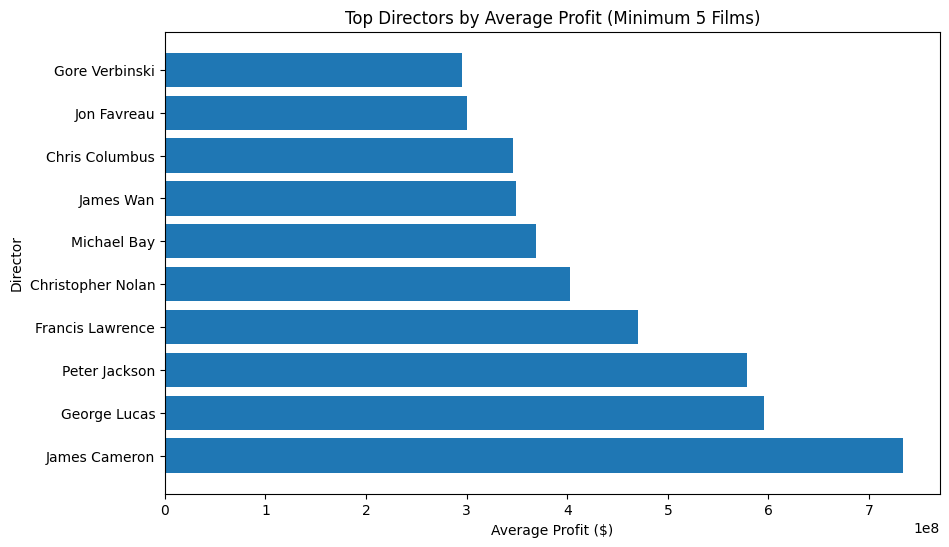

In [42]:
top_directors = (
    director_stats
    .sort_values(by='avg_profit', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_directors.index,
    top_directors['avg_profit']
)

plt.title('Top Directors by Average Profit (Minimum 5 Films)')
plt.xlabel('Average Profit ($)')
plt.ylabel('Director')

plt.show()

## Director Profitability Findings

To improve reliability, only directors with at least five films in the dataset were included.

This reduced the impact of one-off blockbuster successes and provided a fairer comparison of long-term director performance.

The analysis identified several directors who consistently generated strong financial returns across multiple films.

James Cameron, George Lucas and Peter Jackson emerged among the most profitable directors, suggesting that certain directors are able to repeatedly deliver commercially successful films.


In [43]:
year_profit = (
    clean_df.groupby('release_year')['profit']
    .mean()
)

year_profit.tail(10)

,profit
release_year,
2007,8.361142e+07
2008,7.649776e+07
2009,8.959750e+07
2010,7.919671e+07
2011,7.683809e+07
2012,1.216450e+08
2013,9.994237e+07
2014,1.261462e+08
2015,1.329160e+08


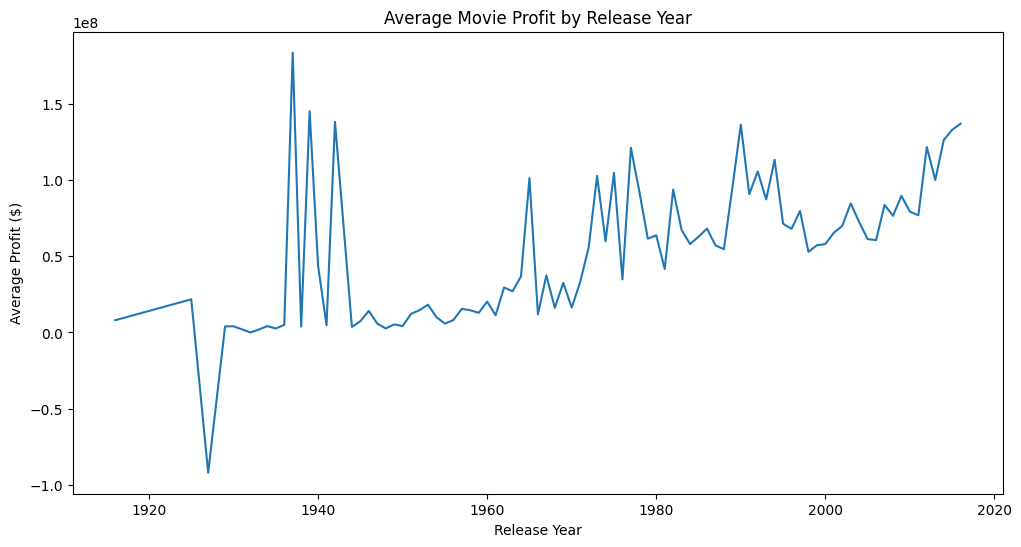

In [44]:
plt.figure(figsize=(12,6))

year_profit.plot()

plt.title('Average Movie Profit by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Profit ($)')

plt.show()

## Profitability Over Time Findings

Average movie profitability showed an upward long-term trend, although early years in the dataset exhibited substantial volatility due to smaller sample sizes.

From the 1970s onwards, profitability appears more stable, with a gradual upward trend visible through the 2000s and 2010s.

This may reflect growth in global audiences, international distribution and the increasing importance of major franchise films.

The analysis highlights the importance of considering sample size when interpreting historical trends, as years with relatively few films can produce misleading averages.

In [45]:
movies_per_year = clean_df['release_year'].value_counts().sort_index()

movies_per_year.tail(20)

,count
release_year,
1997,76
1998,88
1999,106
2000,107
2001,122
2002,131
2003,108
2004,137
2005,143


In [46]:
clean_df.to_csv('movie_profitability_cleaned.csv', index=False)

In [47]:
import os

os.listdir()

['.config',
 'drive',
 'cleaned_movies.csv',
 'movie_profitability_cleaned.csv',
 'movie_dataset.csv',
 'sample_data']

In [48]:
from google.colab import files

files.download('movie_profitability_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>